In [ ]:
import sys

sys.path.append('..')

from src.polynomial_model import (
    train_polynomial_model,
    polynomial_metrics
)

In [ ]:
from src.polynomial_model import (
    train_polynomial_model,
    polynomial_metrics
)

In [ ]:
import pandas as pd

PROCESSED_DATA_DIR = project_root / "data" / "processed"
trend_df = pd.read_csv(PROCESSED_DATA_DIR / "climate_trend_clean.csv")


NameError: name 'project_root' is not defined

In [ ]:
model, polynomial, predictions = (
    train_polynomial_model(
        trend_df,
        degree=2
    )
)

In [ ]:
metrics = polynomial_metrics(
    trend_df["Temperature_Anomaly"],
    predictions
)

metrics

{'MAE': 0.0970459416320579,
 'RMSE': np.float64(0.12035372726621742),
 'R2': 0.9096860678516216}

NameError: name 'GRAPHS_DIR' is not defined

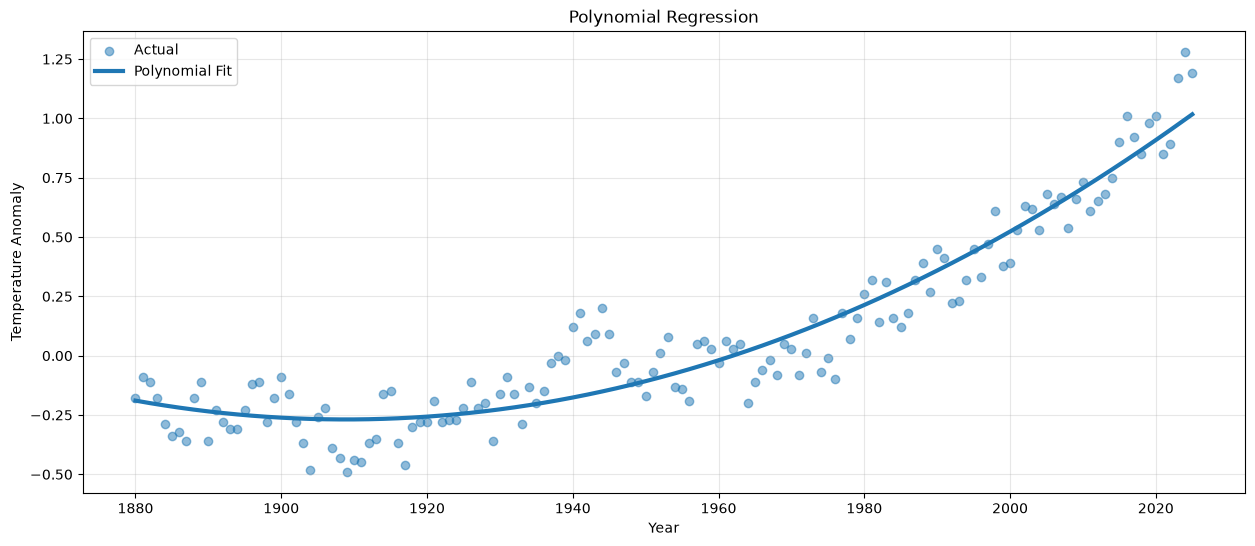

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.scatter(
    trend_df["Year"],
    trend_df["Temperature_Anomaly"],
    alpha=0.5,
    label="Actual"
)

plt.plot(
    trend_df["Year"],
    predictions,
    linewidth=3,
    label="Polynomial Fit"
)

plt.legend()

plt.title("Polynomial Regression")

plt.xlabel("Year")

plt.ylabel("Temperature Anomaly")

plt.grid(alpha=0.3)

plt.savefig(
    GRAPHS_DIR / "polynomial_curve.png",
    dpi=300
)

plt.show()

plt.scatter(
    trend_df["Year"],
    trend_df["Temperature_Anomaly"],
    alpha=0.5,
    label="Actual"
)

plt.plot(
    trend_df["Year"],
    predictions,
    linewidth=3,
    label="Polynomial Fit"
)

plt.legend()

plt.title(
    "Polynomial Regression"
)

plt.xlabel("Year")

plt.ylabel(
    "Temperature Anomaly"
)

plt.grid(alpha=0.3)

plt.savefig(
    GRAPHS_DIR /
    "polynomial_curve.png",
    dpi=300
)

plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

linear_model = LinearRegression()
linear_model.fit(trend_df[["Year"]], trend_df["Temperature_Anomaly"])
linear_predictions = linear_model.predict(trend_df[["Year"]])

linear_model = LinearRegression()
linear_model.fit(trend_df[["Year"]], trend_df["Temperature_Anomaly"])
linear_predictions = linear_model.predict(trend_df[["Year"]])

linear_metrics = {
    "R2": r2_score(trend_df["Temperature_Anomaly"], linear_predictions),
    "MAE": mean_absolute_error(trend_df["Temperature_Anomaly"], linear_predictions),
    "RMSE": root_mean_squared_error(trend_df["Temperature_Anomaly"], linear_predictions),
}

comparison = pd.DataFrame({
    "Model": ["Linear", "Polynomial"],
    "R2": [linear_metrics["R2"], metrics["R2"]],
    "MAE": [linear_metrics["MAE"], metrics["MAE"]],
    "RMSE": [linear_metrics["RMSE"], metrics["RMSE"]],
})

comparison

comparison

,Model,R2,MAE,RMSE
0,Linear,0.766687,0.157775,0.193442
1,Polynomial,0.909686,0.097046,0.120354


In [ ]:
TABLES_DIR = project_root / "data" / "tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

comparison.to_csv(
    TABLES_DIR / "model_comparison.csv",
    index=False
)

In [ ]:
from src.climate_features import (
    calculate_yearly_change
)

In [ ]:
trend_df = calculate_yearly_change(
    trend_df
)

trend_df.head()

,Year,Temperature_Anomaly,Yearly_Change
0,1880,-0.18,NaN
1,1881,-0.09,0.09
2,1882,-0.11,-0.02
3,1883,-0.18,-0.07
4,1884,-0.29,-0.11


In [ ]:
trend_df.to_csv(
    TABLES_DIR /
    "yearly_change.csv",
    index=False
)

In [3]:
import sys
from pathlib import Path
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
from src.climate_features import calculate_yearly_change



In [6]:
import pandas as pd

try:
    trend_df
except NameError:
    try:
        trend_df
    except NameError:
        PROCESSED_DATA_DIR = Path.cwd().parent / "data" / "processed"
        trend_df = pd.read_csv(PROCESSED_DATA_DIR / "climate_trend_clean.csv")

    trend_df = calculate_yearly_change(trend_df)

    trend_df.head()

trend_df = calculate_yearly_change(trend_df)

trend_df.head()

,Year,Temperature_Anomaly,Yearly_Change
0,1880,-0.18,NaN
1,1881,-0.09,0.09
2,1882,-0.11,-0.02
3,1883,-0.18,-0.07
4,1884,-0.29,-0.11


In [8]:
TABLES_DIR = PROCESSED_DATA_DIR.parent / "tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

trend_df.to_csv(
    TABLES_DIR /
    "yearly_change.csv",
    index=False
)

In [9]:
trend_df["Cumulative_Temperature"] = (
    trend_df["Temperature_Anomaly"]
    .cumsum()
)

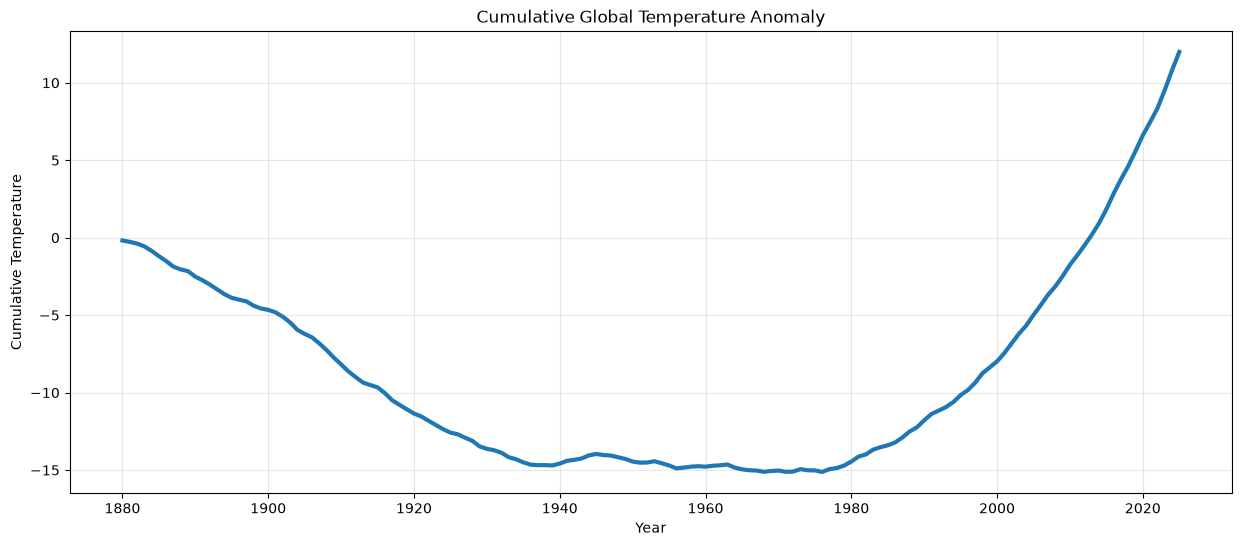

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(
    trend_df["Year"],
    trend_df["Cumulative_Temperature"],
    linewidth=3
)

plt.title(
    "Cumulative Global Temperature Anomaly"
)

plt.xlabel("Year")

plt.ylabel(
    "Cumulative Temperature"
)

plt.grid(alpha=0.3)

GRAPHS_DIR = PROCESSED_DATA_DIR.parent / "graphs"
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

plt.savefig(
    GRAPHS_DIR / "cumulative_warming.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
trend_df["Record_High"] = (
    trend_df["Temperature_Anomaly"]
    ==
    trend_df["Temperature_Anomaly"].cummax()
)

records = trend_df[
    trend_df["Record_High"]
]

records

,Year,Temperature_Anomaly,Yearly_Change,Cumulative_Temperature,Record_High
0,1880,-0.18,NaN,-0.18,True
1,1881,-0.09,0.09,-0.27,True
20,1900,-0.09,0.09,-4.66,True
51,1931,-0.09,0.07,-13.72,True
57,1937,-0.03,0.12,-14.68,True
58,1938,0.00,0.03,-14.68,True
60,1940,0.12,0.14,-14.58,True
61,1941,0.18,0.06,-14.40,True
64,1944,0.20,0.11,-14.05,True
100,1980,0.26,0.10,-14.45,True


In [14]:
records.to_csv(
    TABLES_DIR /
    "climate_records.csv",
    index=False
)

In [15]:
trend_df["Decade"] = (
    trend_df["Year"] // 10
) * 10

In [16]:
decade_stats = (
    trend_df
    .groupby("Decade")
    .agg({
        "Temperature_Anomaly":[
            "mean",
            "min",
            "max",
            "std"
        ]
    })
)

In [17]:
decade_stats.columns = [
    "Mean",
    "Minimum",
    "Maximum",
    "Std"
]

decade_stats = (
    decade_stats
    .reset_index()
)

decade_stats

,Decade,Mean,Minimum,Maximum,Std
0,1880,-0.216,-0.36,-0.09,0.102545
1,1890,-0.241,-0.36,-0.11,0.083327
2,1900,-0.317,-0.49,-0.09,0.136467
3,1910,-0.333,-0.46,-0.15,0.111360
4,1920,-0.240,-0.36,-0.11,0.067659
5,1930,-0.123,-0.29,0.00,0.089944
6,1940,0.042,-0.11,0.20,0.114969
7,1950,-0.047,-0.19,0.08,0.104249
8,1960,-0.031,-0.20,0.06,0.083858
9,1970,0.035,-0.10,0.18,0.104695


In [18]:
decade_stats.to_csv(
    TABLES_DIR /
    "decade_statistics.csv",
    index=False
)

In [19]:
warming_rate = (
    trend_df
    .groupby("Decade")[
        "Temperature_Anomaly"
    ]
    .mean()
)

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    warming_rate.index.astype(str),
    warming_rate.values,
    marker="o",
    linewidth=3
)

plt.title(
    "Average Temperature by Decade"
)

plt.xlabel("Decade")

plt.ylabel(
    "Temperature Anomaly"
)

plt.grid(alpha=0.3)

plt.savefig(
    GRAPHS_DIR /
    "decade_warming_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()